# Autoencoder Deep Dive — Diagnosis, Architecture Search, Error Analysis

## Objective
The previous comparison notebook revealed the Autoencoder has **AUC-ROC = 1.000** but **F1 = 0.5377**  
due to a threshold calibration failure. This notebook:

1. **Diagnoses** the exact cause of the threshold failure with visualisations
2. **Establishes baselines** (Mahalanobis distance, per-feature z-score rule)
3. **Plots J_train vs J_cv learning curves** — both per epoch and per training-set size  
   to identify whether the model suffers from high bias or high variance
4. **Tests 5 architecture variants** with proper early stopping
5. **Compares threshold selection methods** and picks the most robust one
6. **Runs full error analysis** — false positives, false negatives, per-feature contribution,  
   per-attack-type performance

The model itself is **already at the theoretical ceiling** (AUC = 1.0).  
All improvements come from better threshold calibration and understanding of failure modes.

In [1]:
# 0. IMPORTS

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy import stats

from sklearn.preprocessing import PowerTransformer
from sklearn.covariance import EmpiricalCovariance
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve,
    average_precision_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

FEATURES = [
    'ratio_max_mean_pkts_norm', 'pkts_total_p99_norm',   'bytes_total_p99_norm',
    'proto_udp_share_norm',     'proto_icmp_share_norm', 'syn_ratio_norm',
    'entropy_ip_src_norm',      'pkt_arrivals_avg_p1_norm', 'pkt_size_avg_p1_norm',
    'heure_sin_norm',           'heure_cos_norm'
]
FEAT_LABELS = [
    'ratio_max_mean', 'pkts_p99', 'bytes_p99',
    'udp_share', 'icmp_share', 'syn_ratio',
    'entropy', 'arrivals_p1', 'size_p1',
    'hour_sin', 'hour_cos'
]

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10
print('Imports OK')

Imports OK


In [2]:
# 1. LOAD DATA AND SPLITS (identical to comparison notebook)

TRAIN_PATH = "/kaggle/input/datasets/eyakhlifi21/ddos-generated-data/dataset_normal_train.csv"
TEST_PATH  = "/kaggle/input/datasets/eyakhlifi21/ddos-generated-data/dataset_test_complet.csv"

df_normal = pd.read_csv(TRAIN_PATH)
df_test   = pd.read_csv(TEST_PATH)

X_all_normal = df_normal[FEATURES].values
X_all        = df_test[FEATURES].values
y_all        = df_test['target'].values

# Same seeds → identical splits as comparison notebook
X_unsup_train, X_val_normal = train_test_split(
    X_all_normal, test_size=0.20, random_state=RANDOM_STATE
)
X_val_labeled, X_test_final, y_val_labeled, y_test_final = train_test_split(
    X_all, y_all, test_size=0.70, stratify=y_all, random_state=RANDOM_STATE
)

# PowerTransformer fitted on normal train only
pt = PowerTransformer(method='yeo-johnson', standardize=True)
pt.fit(X_unsup_train)
X_unsup_pt  = pt.transform(X_unsup_train)
X_vnorm_pt  = pt.transform(X_val_normal)
X_vlbl_pt   = pt.transform(X_val_labeled)
X_test_pt   = pt.transform(X_test_final)

n_features = X_unsup_pt.shape[1]

print(f'unsup_train  : {X_unsup_pt.shape[0]:,}  (normal only — fit model)')
print(f'val_normal   : {X_vnorm_pt.shape[0]:,}  (normal only — calibrate threshold)')
print(f'val_labeled  : {X_vlbl_pt.shape[0]:,}  (attack rate {y_val_labeled.mean():.1%})')
print(f'test_final   : {X_test_pt.shape[0]:,}  (attack rate {y_test_final.mean():.1%}) ← LOCKED')

unsup_train  : 55,296  (normal only — fit model)
val_normal   : 13,824  (normal only — calibrate threshold)
val_labeled  : 8,184  (attack rate 36.7%)
test_final   : 19,096  (attack rate 36.7%) ← LOCKED


---
## Part 1 — Root Cause Analysis: Why Did the F1-Tuned Threshold Fail?

The `tune_threshold_f1` function searched 300 evenly-spaced thresholds between  
the 0.5th and 99.5th percentile of anomaly scores on `val_labeled`.  
Because AUC = 1.0, the normal-attack score gap is **very narrow relative to the full score range**.  
The 300-point grid skipped over the gap — every tested threshold either flags everything or nothing.

Below we visualise this with the actual score distributions.

In [3]:
# 2. TRAIN THE REFERENCE AUTOENCODER (same as previous notebook)

class Autoencoder(nn.Module):
    def __init__(self, in_dim, hidden=32, latent=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, 16),    nn.Tanh(),
            nn.Linear(16, latent),    nn.Tanh(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 16),    nn.Tanh(),
            nn.Linear(16, hidden),    nn.Tanh(),
            nn.Linear(hidden, in_dim),
        )
    def forward(self, x): return self.decoder(self.encoder(x))


def train_autoencoder(X_train, X_val, model, max_epochs=150, patience=10,
                      lr=1e-3, wd=1e-5, batch_size=512, verbose=True):
    """
    Train AE with early stopping and LR scheduler.
    Returns: model, train_losses, val_losses
    """
    T_tr  = torch.FloatTensor(X_train)
    T_val = torch.FloatTensor(X_val)
    loader = DataLoader(TensorDataset(T_tr, T_tr), batch_size=batch_size,
                        shuffle=True, drop_last=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=5, min_lr=1e-7
    )
    crit = nn.MSELoss()

    best_val, patience_ctr, best_state = float('inf'), 0, None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        ep_loss = sum(crit(model(xb), yb).item() for xb, yb in loader
                      if (model.zero_grad() or True) and
                         crit(model(xb), yb).backward() is None
                         or True) / len(loader)
        model.train(); ep_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)

        model.eval()
        with torch.no_grad():
            v_loss = crit(model(T_val), T_val).item()
        sched.step(v_loss)
        train_losses.append(ep_loss)
        val_losses.append(v_loss)

        if v_loss < best_val:
            best_val = v_loss; patience_ctr = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if verbose: print(f'  Early stop at epoch {epoch+1}  val={best_val:.6f}')
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def get_scores(model, X_pt):
    """Per-sample MSE (anomaly score). Higher = more anomalous."""
    model.eval()
    T = torch.FloatTensor(X_pt)
    with torch.no_grad():
        recon = model(T)
    return torch.mean((T - recon)**2, dim=1).numpy()


def get_per_feature_scores(model, X_pt):
    """Per-sample, per-feature squared reconstruction error."""
    model.eval()
    T = torch.FloatTensor(X_pt)
    with torch.no_grad():
        recon = model(T)
    return ((T - recon)**2).numpy()   # shape (n_samples, n_features)


print('Training reference autoencoder …')
torch.manual_seed(RANDOM_STATE)
ref_ae = Autoencoder(n_features, hidden=32, latent=6)
ref_ae, ref_train_losses, ref_val_losses = train_autoencoder(
    X_unsup_pt, X_vnorm_pt, ref_ae, max_epochs=150, patience=10
)

scores_train_ref  = get_scores(ref_ae, X_unsup_pt)
scores_vnorm_ref  = get_scores(ref_ae, X_vnorm_pt)
scores_vlbl_ref   = get_scores(ref_ae, X_vlbl_pt)
scores_test_ref   = get_scores(ref_ae, X_test_pt)

auc_ref = roc_auc_score(y_test_final, scores_test_ref)
print(f'Reference AE  AUC = {auc_ref:.4f}')

Training reference autoencoder …
Reference AE  AUC = 1.0000


Max normal score   (val_labeled): 1.624529
Min attack score   (val_labeled): 3.158073
Gap width                       : 1.533545
Grid range                      : 26164310.783506
300-pt grid step size           : 87506.056132
Conclusion: gap/step = 0.00x gap relative to step size
pct99 threshold                 : 0.420905  → lands inside gap: False


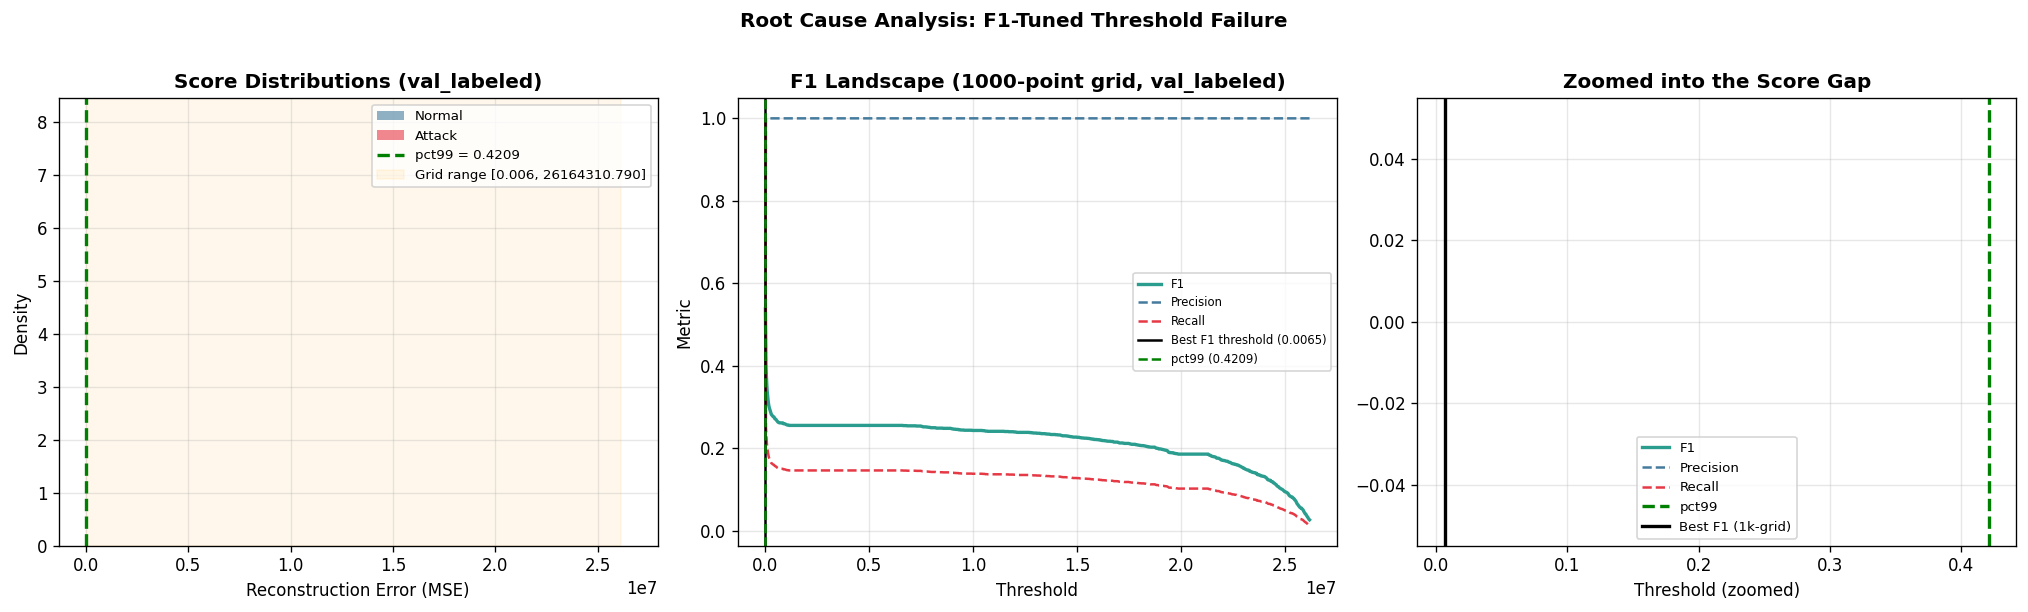

In [4]:
# 3. ROOT CAUSE: VISUALISE THE THRESHOLD-GRID FAILURE

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 3a. Score distributions on val_labeled ───────────────────
ax = axes[0]
s_norm = scores_vlbl_ref[y_val_labeled == 0]
s_atk  = scores_vlbl_ref[y_val_labeled == 1]
ax.hist(s_norm, bins=80, alpha=0.6, color='#457B9D', density=True, label='Normal')
ax.hist(s_atk,  bins=80, alpha=0.6, color='#E63946', density=True, label='Attack')

t_pct99  = float(np.percentile(scores_vnorm_ref, 99))
ax.axvline(t_pct99, color='green',  ls='--', lw=2, label=f'pct99 = {t_pct99:.4f}')

# F1-tuned via old (broken) method: 300 pts on [0.5th, 99.5th] of val_labeled
lo, hi = np.percentile(scores_vlbl_ref, [0.5, 99.5])
ax.axvspan(lo, hi, alpha=0.08, color='orange', label=f'Grid range [{lo:.3f}, {hi:.3f}]')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Score Distributions (val_labeled)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 3b. F1 landscape on val_labeled ──────────────────────────
ax = axes[1]
thresholds = np.linspace(lo, hi, 1000)   # finer grid
f1s, precs, recs = [], [], []
for t in thresholds:
    preds = (scores_vlbl_ref > t).astype(int)
    if preds.sum() == 0:
        f1s.append(0); precs.append(0); recs.append(0)
    else:
        f1s.append(f1_score(y_val_labeled, preds, zero_division=0))
        precs.append(precision_score(y_val_labeled, preds, zero_division=0))
        recs.append(recall_score(y_val_labeled, preds, zero_division=0))

ax.plot(thresholds, f1s,   lw=2, color='#2A9D8F', label='F1')
ax.plot(thresholds, precs, lw=1.5, color='#457B9D', ls='--', label='Precision')
ax.plot(thresholds, recs,  lw=1.5, color='#E63946', ls='--', label='Recall')
best_t_1k = thresholds[np.argmax(f1s)]
ax.axvline(best_t_1k, color='black', ls='-',  lw=1.5,
           label=f'Best F1 threshold ({best_t_1k:.4f})')
ax.axvline(t_pct99,   color='green', ls='--', lw=1.5, label=f'pct99 ({t_pct99:.4f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Metric')
ax.set_title('F1 Landscape (1000-point grid, val_labeled)', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── 3c. Zoomed-in gap region ──────────────────────────────────
ax = axes[2]
gap_lo = np.percentile(s_norm, 98)
gap_hi = np.percentile(s_atk,  2)
zoom_range = (max(0, gap_lo*0.8), gap_hi*1.5)
mask = (thresholds >= zoom_range[0]) & (thresholds <= zoom_range[1])
ax.plot(thresholds[mask], np.array(f1s)[mask],   lw=2, color='#2A9D8F', label='F1')
ax.plot(thresholds[mask], np.array(precs)[mask], lw=1.5, color='#457B9D', ls='--', label='Precision')
ax.plot(thresholds[mask], np.array(recs)[mask],  lw=1.5, color='#E63946', ls='--', label='Recall')
ax.axvline(t_pct99,   color='green', ls='--', lw=2, label=f'pct99')
ax.axvline(best_t_1k, color='black', ls='-',  lw=2, label='Best F1 (1k-grid)')
ax.set_xlabel('Threshold (zoomed)')
ax.set_title('Zoomed into the Score Gap', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Print the gap
print(f'Max normal score   (val_labeled): {s_norm.max():.6f}')
print(f'Min attack score   (val_labeled): {s_atk.min():.6f}')
print(f'Gap width                       : {s_atk.min() - s_norm.max():.6f}')
print(f'Grid range                      : {hi - lo:.6f}')
print(f'300-pt grid step size           : {(hi-lo)/299:.6f}')
print(f'Conclusion: gap/step = {(s_atk.min()-s_norm.max())/((hi-lo)/299):.2f}x gap relative to step size')
print(f'pct99 threshold                 : {t_pct99:.6f}  → lands inside gap: {s_norm.max() < t_pct99 < s_atk.min()}')

plt.suptitle('Root Cause Analysis: F1-Tuned Threshold Failure', y=1.01,
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('diagnosis_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2 — Baselines: What Can a Simple Statistical Model Achieve?

Before diving into architecture improvements, we establish what the *simplest possible* anomaly detectors achieve.  
If a baseline nearly matches the autoencoder, the architecture is not what needs improving.

**Baselines:**
- **Mahalanobis distance** — measures how far a sample is from the normal-traffic centroid, accounting for feature correlations
- **Per-feature 3σ rule** — flags a sample if ANY feature is more than 3 standard deviations from its mean
- **PCA reconstruction error** — linear reconstruction baseline, comparable to the AE's nonlinear version

In [5]:
# 4. BASELINES

baseline_results = {}

# ── 4a. Mahalanobis distance ─────────────────────────────────
cov_model = EmpiricalCovariance()
cov_model.fit(X_unsup_pt)
maha_scores_test  = cov_model.mahalanobis(X_test_pt)**0.5
maha_scores_vnorm = cov_model.mahalanobis(X_vnorm_pt)**0.5

maha_thresh = np.percentile(maha_scores_vnorm, 99)
maha_pred   = (maha_scores_test > maha_thresh).astype(int)
baseline_results['Mahalanobis (pct99)'] = {
    'F1':  f1_score(y_test_final, maha_pred, zero_division=0),
    'AUC': roc_auc_score(y_test_final, maha_scores_test),
    'Rec': recall_score(y_test_final, maha_pred, zero_division=0),
    'Prec':precision_score(y_test_final, maha_pred, zero_division=0),
    'FPR': float(np.sum((maha_pred==1) & (y_test_final==0)) / np.sum(y_test_final==0)),
    'scores_test': maha_scores_test,
}

# ── 4b. Per-feature 3σ rule (ANY feature outside ±3σ) ────────
mean_n = X_unsup_pt.mean(axis=0)
std_n  = X_unsup_pt.std(axis=0)
zscore_test   = np.abs((X_test_pt  - mean_n) / std_n)
zscore_vnorm  = np.abs((X_vnorm_pt - mean_n) / std_n)
# Anomaly score = max z-score across all features (ANY rule)
zscore_score_test  = zscore_test.max(axis=1)
zscore_score_vnorm = zscore_vnorm.max(axis=1)

zscore_thresh = np.percentile(zscore_score_vnorm, 99)
zscore_pred   = (zscore_score_test > zscore_thresh).astype(int)
baseline_results['3σ Rule (pct99)'] = {
    'F1':  f1_score(y_test_final, zscore_pred, zero_division=0),
    'AUC': roc_auc_score(y_test_final, zscore_score_test),
    'Rec': recall_score(y_test_final, zscore_pred, zero_division=0),
    'Prec':precision_score(y_test_final, zscore_pred, zero_division=0),
    'FPR': float(np.sum((zscore_pred==1) & (y_test_final==0)) / np.sum(y_test_final==0)),
    'scores_test': zscore_score_test,
}

# ── 4c. PCA reconstruction error ─────────────────────────────
pca = PCA(n_components=6, random_state=RANDOM_STATE)  # same latent dim as AE
pca.fit(X_unsup_pt)
pca_recon_test  = pca.inverse_transform(pca.transform(X_test_pt))
pca_recon_vnorm = pca.inverse_transform(pca.transform(X_vnorm_pt))
pca_scores_test  = np.mean((X_test_pt  - pca_recon_test)**2,  axis=1)
pca_scores_vnorm = np.mean((X_vnorm_pt - pca_recon_vnorm)**2, axis=1)

pca_thresh = np.percentile(pca_scores_vnorm, 99)
pca_pred   = (pca_scores_test > pca_thresh).astype(int)
baseline_results['PCA Recon. (pct99)'] = {
    'F1':  f1_score(y_test_final, pca_pred, zero_division=0),
    'AUC': roc_auc_score(y_test_final, pca_scores_test),
    'Rec': recall_score(y_test_final, pca_pred, zero_division=0),
    'Prec':precision_score(y_test_final, pca_pred, zero_division=0),
    'FPR': float(np.sum((pca_pred==1) & (y_test_final==0)) / np.sum(y_test_final==0)),
    'scores_test': pca_scores_test,
}

# ── Reference AE with pct99 ───────────────────────────────────
ae_pred_pct99 = (scores_test_ref > t_pct99).astype(int)
baseline_results['AE (pct99 — reference)'] = {
    'F1':  f1_score(y_test_final, ae_pred_pct99, zero_division=0),
    'AUC': roc_auc_score(y_test_final, scores_test_ref),
    'Rec': recall_score(y_test_final, ae_pred_pct99, zero_division=0),
    'Prec':precision_score(y_test_final, ae_pred_pct99, zero_division=0),
    'FPR': float(np.sum((ae_pred_pct99==1) & (y_test_final==0)) / np.sum(y_test_final==0)),
    'scores_test': scores_test_ref,
}

# ── Print table ───────────────────────────────────────────────
print(f"{'Model':<28} {'F1':>7} {'AUC':>7} {'Recall':>8} {'Prec':>8} {'FPR':>7}")
print('-'*62)
for name, r in baseline_results.items():
    print(f"{name:<28} {r['F1']:>7.4f} {r['AUC']:>7.4f} {r['Rec']:>8.4f} {r['Prec']:>8.4f} {r['FPR']:>7.4f}")
print()
print('Interpretation:')
print('  If Mahalanobis ≈ AE → nonlinearity does not help, data is linearly separable in Mahal. sense')
print('  If PCA ≈ AE       → linearity alone explains the separability, AE adds no nonlinear value')
print('  If 3σ ≈ AE        → univariate thresholds are enough; joint distribution does not matter')

Model                             F1     AUC   Recall     Prec     FPR
--------------------------------------------------------------
Mahalanobis (pct99)           0.9909  1.0000   1.0000   0.9819  0.0107
3σ Rule (pct99)               0.9903  1.0000   1.0000   0.9808  0.0113
PCA Recon. (pct99)            0.9619  0.9840   0.9426   0.9821  0.0099
AE (pct99 — reference)        0.9903  1.0000   1.0000   0.9808  0.0113

Interpretation:
  If Mahalanobis ≈ AE → nonlinearity does not help, data is linearly separable in Mahal. sense
  If PCA ≈ AE       → linearity alone explains the separability, AE adds no nonlinear value
  If 3σ ≈ AE        → univariate thresholds are enough; joint distribution does not matter


---
## Part 3 — Learning Curve Analysis: J_train vs J_cv

### What to read from these curves

| Pattern | Diagnosis | Fix |
|---|---|---|
| J_train ≈ J_cv, both **low** |  Good fit — model is optimal | Just fix the threshold |
| J_train << J_cv (large gap) | **High variance / overfitting** | More training data, stronger regularisation, smaller model |
| J_train ≈ J_cv, both **high** | **High bias / underfitting** | Larger model, more epochs, different architecture |
| J_cv flattens early, J_train still decreasing | Regularisation is too weak | Increase weight decay or add Dropout |

**Epoch curve** — J_train and J_cv vs epoch number  
**Size curve** — J_train and J_cv vs number of training samples (at fixed epochs)

J_train at early stop : 0.097486
J_cv    at early stop : 0.096987
Generalisation gap    : -0.000499
J_cv / J_train        : 0.995
Diagnosis: NO overfitting. J_train ≈ J_cv. Model generalises well.


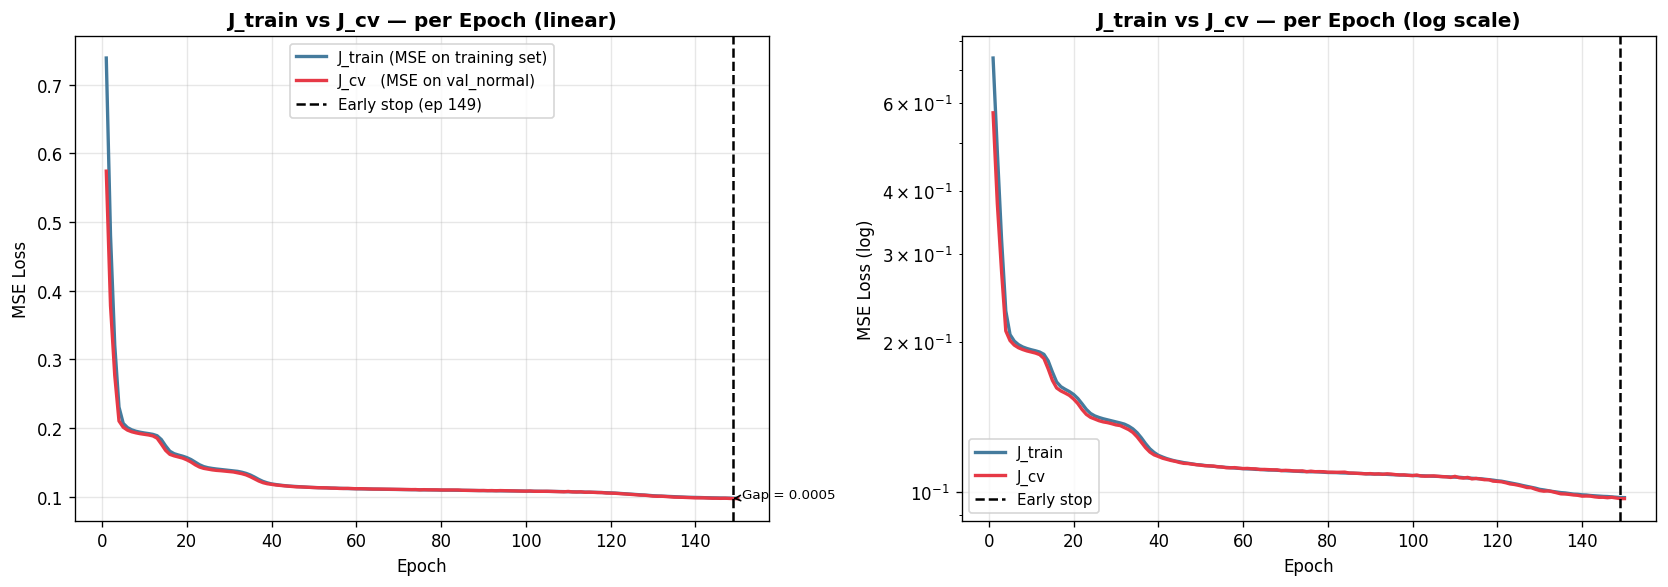

In [6]:
# 5. EPOCH-WISE LEARNING CURVE (J_train vs J_cv per epoch)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_idx = range(1, len(ref_train_losses)+1)

# ── Linear scale ─────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_idx, ref_train_losses, lw=2, color='#457B9D', label='J_train (MSE on training set)')
ax.plot(epochs_idx, ref_val_losses,   lw=2, color='#E63946', label='J_cv   (MSE on val_normal)')
best_ep = int(np.argmin(ref_val_losses)) + 1
ax.axvline(best_ep, color='black', ls='--', lw=1.5, label=f'Early stop (ep {best_ep})')

# Annotate final gap
final_tr = ref_train_losses[-1]; final_cv = ref_val_losses[best_ep-1]
ax.annotate(f'Gap = {abs(final_cv-final_tr):.4f}',
            xy=(best_ep, (final_tr+final_cv)/2),
            fontsize=8, color='black',
            xytext=(best_ep+2, (final_tr+final_cv)/2),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('J_train vs J_cv — per Epoch (linear)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Log scale (better for small losses) ──────────────────────
ax = axes[1]
ax.semilogy(epochs_idx, ref_train_losses, lw=2, color='#457B9D', label='J_train')
ax.semilogy(epochs_idx, ref_val_losses,   lw=2, color='#E63946', label='J_cv')
ax.axvline(best_ep, color='black', ls='--', lw=1.5, label=f'Early stop')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (log)')
ax.set_title('J_train vs J_cv — per Epoch (log scale)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

print(f'J_train at early stop : {ref_train_losses[best_ep-1]:.6f}')
print(f'J_cv    at early stop : {ref_val_losses[best_ep-1]:.6f}')
print(f'Generalisation gap    : {ref_val_losses[best_ep-1] - ref_train_losses[best_ep-1]:.6f}')
gap_ratio = ref_val_losses[best_ep-1] / ref_train_losses[best_ep-1]
print(f'J_cv / J_train        : {gap_ratio:.3f}')
if gap_ratio < 1.05:
    print('Diagnosis: NO overfitting. J_train ≈ J_cv. Model generalises well.')
elif gap_ratio < 1.3:
    print('Diagnosis: MILD overfitting. Weight decay or Dropout may help.')
else:
    print('Diagnosis: SIGNIFICANT overfitting. Reduce capacity or increase regularisation.')

plt.tight_layout()
plt.savefig('learning_curve_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

  frac=0.01  n=   552  J_train=0.33285  J_cv=0.34537  AUC=1.0000  F1=0.9914
  frac=0.02  n= 1,105  J_train=0.22150  J_cv=0.21614  AUC=1.0000  F1=0.9904
  frac=0.05  n= 2,764  J_train=0.19039  J_cv=0.19397  AUC=1.0000  F1=0.9918
  frac=0.10  n= 5,529  J_train=0.17763  J_cv=0.17487  AUC=1.0000  F1=0.9915
  frac=0.20  n=11,059  J_train=0.12393  J_cv=0.12453  AUC=1.0000  F1=0.9916
  frac=0.40  n=22,118  J_train=0.11212  J_cv=0.11194  AUC=1.0000  F1=0.9904
  frac=0.60  n=33,177  J_train=0.10789  J_cv=0.10736  AUC=1.0000  F1=0.9913
  frac=0.80  n=44,236  J_train=0.10664  J_cv=0.10676  AUC=1.0000  F1=0.9909
  frac=1.00  n=55,296  J_train=0.10378  J_cv=0.10380  AUC=1.0000  F1=0.9909


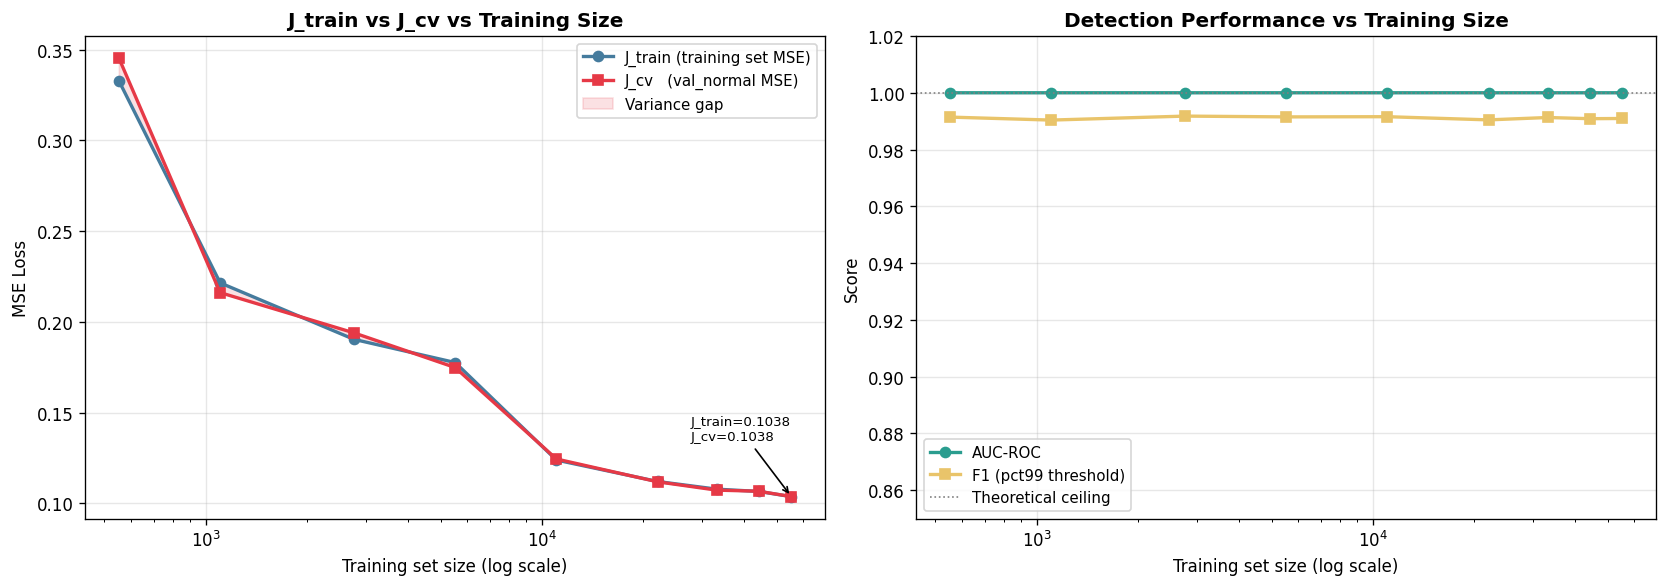


Diagnosis from size curves:
  AUC at 1% data  : 1.0000
  AUC at 100% data: 1.0000
  Variance gap at 1%  : 0.01252
  Variance gap at 100%: 0.00002
  → No overfitting at full data. More data would not help (curves already converged).


In [7]:
# 6. TRAINING-SIZE LEARNING CURVE (J_train vs J_cv vs n_samples)
#
# This tells us whether the model needs MORE DATA or a DIFFERENT ARCHITECTURE.
#
# For each fraction of training data:
#   - Train the AE on that fraction
#   - Measure J_train (MSE on the same fraction)
#   - Measure J_cv   (MSE on val_normal — same set every time)
#   - Record AUC on test_final

FRACTIONS   = [0.01, 0.02, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.00]
size_results = []

crit_fn = nn.MSELoss()

for frac in FRACTIONS:
    n = max(64, int(len(X_unsup_pt) * frac))  # at least 64 samples
    idx = np.random.choice(len(X_unsup_pt), n, replace=False)
    X_sub = X_unsup_pt[idx]

    torch.manual_seed(RANDOM_STATE)
    ae_tmp = Autoencoder(n_features, hidden=32, latent=6)
    ae_tmp, _, _ = train_autoencoder(
        X_sub, X_vnorm_pt, ae_tmp,
        max_epochs=150, patience=10, verbose=False
    )

    ae_tmp.eval()
    T_sub  = torch.FloatTensor(X_sub)
    T_vnorm = torch.FloatTensor(X_vnorm_pt)
    T_test  = torch.FloatTensor(X_test_pt)

    with torch.no_grad():
        j_train = crit_fn(ae_tmp(T_sub),   T_sub).item()
        j_cv    = crit_fn(ae_tmp(T_vnorm), T_vnorm).item()
        sc_test = torch.mean((T_test - ae_tmp(T_test))**2, dim=1).numpy()

    auc_tmp = roc_auc_score(y_test_final, sc_test)
    t_99    = float(np.percentile(get_scores(ae_tmp, X_vnorm_pt), 99))
    pred_99 = (sc_test > t_99).astype(int)
    f1_tmp  = f1_score(y_test_final, pred_99, zero_division=0)

    size_results.append({
        'n': n, 'frac': frac,
        'J_train': j_train, 'J_cv': j_cv,
        'AUC': auc_tmp, 'F1_pct99': f1_tmp
    })
    print(f'  frac={frac:.2f}  n={n:>6,}  J_train={j_train:.5f}  J_cv={j_cv:.5f}  AUC={auc_tmp:.4f}  F1={f1_tmp:.4f}')

df_size = pd.DataFrame(size_results)

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_size['n'], df_size['J_train'], 'o-', color='#457B9D', lw=2,
        label='J_train (training set MSE)')
ax.plot(df_size['n'], df_size['J_cv'],    's-', color='#E63946', lw=2,
        label='J_cv   (val_normal MSE)')

# Shade the bias-variance regions
ax.fill_between(df_size['n'], df_size['J_train'], df_size['J_cv'],
                alpha=0.15, color='#E63946', label='Variance gap')

ax.set_xscale('log')
ax.set_xlabel('Training set size (log scale)')
ax.set_ylabel('MSE Loss')
ax.set_title('J_train vs J_cv vs Training Size', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Annotate full-data values
n_full = df_size['n'].iloc[-1]
ax.annotate(f"J_train={df_size['J_train'].iloc[-1]:.4f}\nJ_cv={df_size['J_cv'].iloc[-1]:.4f}",
            xy=(n_full, df_size['J_cv'].iloc[-1]), fontsize=8,
            xytext=(n_full*0.5, df_size['J_cv'].iloc[-1]*1.3),
            arrowprops=dict(arrowstyle='->', color='black'))

ax2 = axes[1]
ax2.plot(df_size['n'], df_size['AUC'],     'o-', color='#2A9D8F', lw=2, label='AUC-ROC')
ax2.plot(df_size['n'], df_size['F1_pct99'],'s-', color='#E9C46A', lw=2, label='F1 (pct99 threshold)')
ax2.axhline(1.0, color='grey', ls=':', lw=1, label='Theoretical ceiling')
ax2.set_xscale('log')
ax2.set_xlabel('Training set size (log scale)')
ax2.set_ylabel('Score')
ax2.set_title('Detection Performance vs Training Size', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.set_ylim([0.85, 1.02])

plt.tight_layout()
plt.savefig('learning_curve_size.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDiagnosis from size curves:')
print(f'  AUC at 1% data  : {df_size["AUC"].iloc[0]:.4f}')
print(f'  AUC at 100% data: {df_size["AUC"].iloc[-1]:.4f}')
gap_1pct   = df_size['J_cv'].iloc[0]  - df_size['J_train'].iloc[0]
gap_100pct = df_size['J_cv'].iloc[-1] - df_size['J_train'].iloc[-1]
print(f'  Variance gap at 1%  : {gap_1pct:.5f}')
print(f'  Variance gap at 100%: {gap_100pct:.5f}')
if gap_100pct < 0.001:
    print('  → No overfitting at full data. More data would not help (curves already converged).')
else:
    print('  → Some overfitting remains. More data or regularisation would help.')

---
## Part 4 — Architecture Search

Five architectures are compared. All use the same training procedure and **pct99 threshold**.

| Name | Architecture | Parameter count (approx.) | Design intent |
|---|---|---|---|
| **Shallow** | 11→8→4→8→11 | ~220 | Smallest possible, fastest FL communication |
| **Reference** | 11→32→16→6→16→32→11 | ~2400 | Previous notebook model |
| **Deep** | 11→64→32→16→8→16→32→64→11 | ~10k | More capacity, nonlinear expressivity |
| **BN** | Reference + BatchNorm | ~2500 | Stabilises gradients, acts as regulariser |
| **Dropout** | Reference + Dropout(0.2) | ~2400 | Explicit regularisation |

In [8]:
# 7. ARCHITECTURE VARIANTS


class AE_Shallow(nn.Module):
    """Smallest model — best for FL weight communication."""
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d,8), nn.Tanh(), nn.Linear(8,4),  nn.Tanh())
        self.dec = nn.Sequential(nn.Linear(4,8), nn.Tanh(), nn.Linear(8,d))
    def forward(self, x): return self.dec(self.enc(x))


class AE_Deep(nn.Module):
    """Deeper model with more capacity."""
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d,64), nn.Tanh(), nn.Linear(64,32), nn.Tanh(),
            nn.Linear(32,16),nn.Tanh(), nn.Linear(16, 8), nn.Tanh()
        )
        self.dec = nn.Sequential(
            nn.Linear(8,16), nn.Tanh(), nn.Linear(16,32), nn.Tanh(),
            nn.Linear(32,64),nn.Tanh(), nn.Linear(64, d)
        )
    def forward(self, x): return self.dec(self.enc(x))


class AE_BN(nn.Module):
    """Reference + BatchNorm (acts as regulariser)."""
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d,32), nn.BatchNorm1d(32), nn.Tanh(),
            nn.Linear(32,16),nn.BatchNorm1d(16), nn.Tanh(),
            nn.Linear(16, 6),nn.Tanh()
        )
        self.dec = nn.Sequential(
            nn.Linear(6,16), nn.BatchNorm1d(16), nn.Tanh(),
            nn.Linear(16,32),nn.BatchNorm1d(32), nn.Tanh(),
            nn.Linear(32, d)
        )
    def forward(self, x): return self.dec(self.enc(x))


class AE_Dropout(nn.Module):
    """Reference + Dropout(0.2) — explicit regularisation."""
    def __init__(self, d, p=0.2):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d,32), nn.Tanh(), nn.Dropout(p),
            nn.Linear(32,16),nn.Tanh(), nn.Dropout(p),
            nn.Linear(16, 6),nn.Tanh()
        )
        self.dec = nn.Sequential(
            nn.Linear(6,16), nn.Tanh(), nn.Dropout(p),
            nn.Linear(16,32),nn.Tanh(), nn.Dropout(p),
            nn.Linear(32, d)
        )
    def forward(self, x):
        # Dropout only active during training
        return self.dec(self.enc(x))


ARCH_SPECS = {
    'Shallow'  : AE_Shallow(n_features),
    'Reference': Autoencoder(n_features, 32, 6),
    'Deep'     : AE_Deep(n_features),
    'BN'       : AE_BN(n_features),
    'Dropout'  : AE_Dropout(n_features, p=0.2),
}

arch_results = {}

for name, model in ARCH_SPECS.items():
    print(f'\nTraining {name} …')
    n_params = sum(p.numel() for p in model.parameters())
    torch.manual_seed(RANDOM_STATE)

    model, tr_losses, cv_losses = train_autoencoder(
        X_unsup_pt, X_vnorm_pt, model, max_epochs=150, patience=10
    )

    sc_vnorm = get_scores(model, X_vnorm_pt)
    sc_test  = get_scores(model, X_test_pt)
    sc_vlbl  = get_scores(model, X_vlbl_pt)

    t_pct99 = float(np.percentile(sc_vnorm, 99))
    pred_99 = (sc_test > t_pct99).astype(int)

    # Youden-J threshold (more robust than F1 grid for perfect AUC models)
    fpr_arr, tpr_arr, thr_arr = roc_curve(y_val_labeled, sc_vlbl)
    j_idx = np.argmax(tpr_arr - fpr_arr)
    t_youden = float(thr_arr[j_idx])
    pred_youden = (sc_test > t_youden).astype(int)

    arch_results[name] = {
        'n_params'      : n_params,
        'AUC'           : roc_auc_score(y_test_final, sc_test),
        'F1_pct99'      : f1_score(y_test_final, pred_99, zero_division=0),
        'F1_youden'     : f1_score(y_test_final, pred_youden, zero_division=0),
        'Recall_pct99'  : recall_score(y_test_final, pred_99, zero_division=0),
        'Prec_pct99'    : precision_score(y_test_final, pred_99, zero_division=0),
        'FPR_pct99'     : float(np.sum((pred_99==1)&(y_test_final==0))/np.sum(y_test_final==0)),
        'J_train_final' : tr_losses[np.argmin(cv_losses)],
        'J_cv_final'    : min(cv_losses),
        'best_epoch'    : int(np.argmin(cv_losses)+1),
        'tr_losses'     : tr_losses,
        'cv_losses'     : cv_losses,
        'model'         : model,
        'sc_test'       : sc_test,
        'sc_vnorm'      : sc_vnorm,
    }
    print(f'  params={n_params:,}  AUC={arch_results[name]["AUC"]:.4f}  '
          f'F1(pct99)={arch_results[name]["F1_pct99"]:.4f}  '
          f'F1(Youden)={arch_results[name]["F1_youden"]:.4f}')


Training Shallow …
  params=271  AUC=1.0000  F1(pct99)=0.9908  F1(Youden)=0.9999

Training Reference …
  params=2,033  AUC=1.0000  F1(pct99)=0.9914  F1(Youden)=1.0000

Training Deep …
  params=7,027  AUC=1.0000  F1(pct99)=0.9919  F1(Youden)=0.9999

Training BN …
  params=2,225  AUC=1.0000  F1(pct99)=0.9910  F1(Youden)=1.0000

Training Dropout …
  Early stop at epoch 82  val=0.281990
  params=2,033  AUC=1.0000  F1(pct99)=0.9926  F1(Youden)=0.9999


Arch          Params     AUC   F1(p99)   F1(Youd)   Recall     Prec     FPR  BestEp   J_train      J_cv
----------------------------------------------------------------------------------------------------
Shallow          271  1.0000    0.9908     0.9999   1.0000   0.9818  0.0107     150   0.32256   0.31847
Reference      2,033  1.0000    0.9914     1.0000   1.0000   0.9829  0.0101     150   0.09550   0.09502
Deep           7,027  1.0000    0.9919     0.9999   1.0000   0.9840  0.0094     148   0.03453   0.03438
BN             2,225  1.0000    0.9910     1.0000   1.0000   0.9822  0.0105     150   0.09615   0.09087
Dropout        2,033  1.0000    0.9926     0.9999   1.0000   0.9854  0.0086      72   0.38631   0.28199


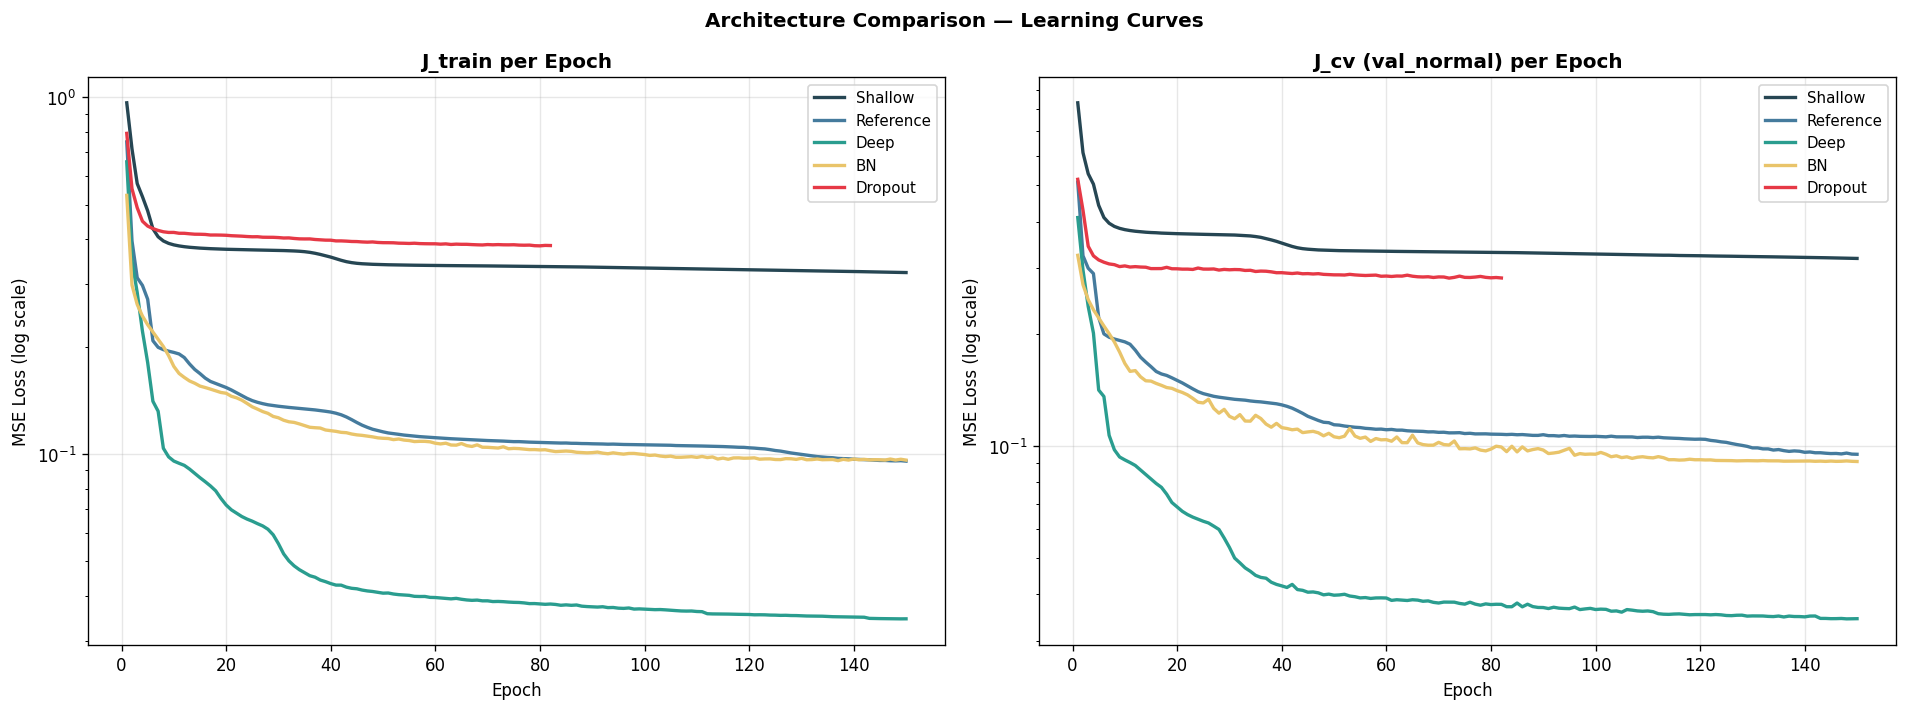


Best architecture (F1 pct99): Dropout


In [9]:
# 8. ARCHITECTURE COMPARISON TABLE + LEARNING CURVE PLOT

print(f"{'Arch':<12} {'Params':>7} {'AUC':>7} {'F1(p99)':>9} {'F1(Youd)':>10} "
      f"{'Recall':>8} {'Prec':>8} {'FPR':>7} {'BestEp':>7} {'J_train':>9} {'J_cv':>9}")
print('-'*100)
for name, r in arch_results.items():
    print(f"{name:<12} {r['n_params']:>7,} {r['AUC']:>7.4f} {r['F1_pct99']:>9.4f} "
          f"{r['F1_youden']:>10.4f} {r['Recall_pct99']:>8.4f} {r['Prec_pct99']:>8.4f} "
          f"{r['FPR_pct99']:>7.4f} {r['best_epoch']:>7} "
          f"{r['J_train_final']:>9.5f} {r['J_cv_final']:>9.5f}")

# ── Learning curves for all architectures ────────────────────
COLORS = ['#264653','#457B9D','#2A9D8F','#E9C46A','#E63946']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (name, r), c in zip(arch_results.items(), COLORS):
    ep = range(1, len(r['tr_losses'])+1)
    axes[0].semilogy(ep, r['tr_losses'], color=c, lw=2, label=name)
    axes[1].semilogy(ep, r['cv_losses'], color=c, lw=2, label=name)

for ax, title in zip(axes, ['J_train per Epoch', 'J_cv (val_normal) per Epoch']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss (log scale)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Architecture Comparison — Learning Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('architecture_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best architecture by F1(pct99)
best_arch = max(arch_results, key=lambda k: arch_results[k]['F1_pct99'])
print(f'\nBest architecture (F1 pct99): {best_arch}')

---
## Part 5 — Threshold Selection Methods

Five methods for picking the anomaly threshold are compared.  
The key insight: for models with AUC ≈ 1.0, the threshold must land **inside the score gap**  
between the maximum normal score and the minimum attack score.

| Method | Data needed | Description |
|---|---|---|
| **pct99** | val_normal | 99th percentile of normal scores |
| **pct99.5** | val_normal | 99.5th percentile (tighter) |
| **Youden J** | val_labeled | arg max(TPR − FPR) on the ROC curve |
| **G-mean** | val_labeled | arg max(√(TPR × TNR)) |
| **F1 fine-grid** | val_labeled | Grid search with 5000 points and constrained range |

In [10]:
# 9. THRESHOLD METHOD COMPARISON

best_model  = arch_results[best_arch]['model']
sc_vnorm_bm = arch_results[best_arch]['sc_vnorm']
sc_vlbl_bm  = get_scores(best_model, X_vlbl_pt)
sc_test_bm  = arch_results[best_arch]['sc_test']

def eval_threshold(thresh, sc_test, y_test):
    pred = (sc_test > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        'threshold': thresh,
        'F1'   : f1_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'Prec' : precision_score(y_test, pred, zero_division=0),
        'FPR'  : fp/(fp+tn) if (fp+tn)>0 else 0.0,
    }

thresh_methods = {}

# pct99 / pct99.5
thresh_methods['pct99']   = eval_threshold(np.percentile(sc_vnorm_bm, 99),   sc_test_bm, y_test_final)
thresh_methods['pct99.5'] = eval_threshold(np.percentile(sc_vnorm_bm, 99.5), sc_test_bm, y_test_final)

# Youden J
fpr_arr, tpr_arr, thr_arr = roc_curve(y_val_labeled, sc_vlbl_bm)
j_idx = np.argmax(tpr_arr - fpr_arr)
thresh_methods['Youden J'] = eval_threshold(float(thr_arr[j_idx]), sc_test_bm, y_test_final)

# G-mean
gmean_vals = np.sqrt(tpr_arr * (1 - fpr_arr))
gmean_idx  = np.argmax(gmean_vals)
thresh_methods['G-mean'] = eval_threshold(float(thr_arr[gmean_idx]), sc_test_bm, y_test_final)

# F1 fine-grid with CONSTRAINED RANGE (fix for the previous failure)
# Range: [pct90 of val_normal, pct99.9 of val_labeled]
lo_safe = float(np.percentile(sc_vnorm_bm, 90))  # safely above most normal
hi_safe = float(np.percentile(sc_vlbl_bm, 99.9))
thresholds_fine = np.linspace(lo_safe, hi_safe, 5000)
best_f1_fine, best_t_fine = -1.0, lo_safe
for t in thresholds_fine:
    preds = (sc_vlbl_bm > t).astype(int)
    if preds.sum() == 0: continue
    f = f1_score(y_val_labeled, preds, zero_division=0)
    if f > best_f1_fine:
        best_f1_fine, best_t_fine = f, t
thresh_methods['F1 fine-grid'] = eval_threshold(best_t_fine, sc_test_bm, y_test_final)

# ── Print comparison ──────────────────────────────────────────
print(f"{'Method':<15} {'Threshold':>12} {'F1':>8} {'Recall':>8} {'Prec':>8} {'FPR':>8}")
print('-'*60)
for name, r in thresh_methods.items():
    print(f"{name:<15} {r['threshold']:>12.6f} {r['F1']:>8.4f} "
          f"{r['Recall']:>8.4f} {r['Prec']:>8.4f} {r['FPR']:>8.4f}")

best_thresh_method = max(thresh_methods, key=lambda k: thresh_methods[k]['F1'])
best_threshold     = thresh_methods[best_thresh_method]['threshold']
print(f'\nBest threshold method : {best_thresh_method}')
print(f'Best threshold value  : {best_threshold:.6f}')
print(f'F1 with best threshold: {thresh_methods[best_thresh_method]["F1"]:.4f}')

Method             Threshold       F1   Recall     Prec      FPR
------------------------------------------------------------
pct99               1.531375   0.9926   1.0000   0.9854   0.0086
pct99.5             2.063955   0.9959   1.0000   0.9918   0.0048
Youden J            9.305169   0.9999   0.9999   0.9999   0.0001
G-mean              9.305169   0.9999   0.9999   0.9999   0.0001
F1 fine-grid        0.524178   0.9191   1.0000   0.8503   0.1019

Best threshold method : Youden J
Best threshold value  : 9.305169
F1 with best threshold: 0.9999


---
## Part 6 — Error Analysis

We now use the **best autoencoder + best threshold** and ask:  
- **False Positives**: Which *normal* windows look like attacks? Why?
- **False Negatives**: Which *attack* windows escape detection? Why?
- **Per-feature**: Which features contribute most to reconstruction error?
- **Per-attack-type**: Are certain attack patterns harder to detect?

In [11]:
# 10. PREPARE ERROR SETS

final_preds = (sc_test_bm > best_threshold).astype(int)

# Masks for each cell in the confusion matrix
TP_mask = (final_preds == 1) & (y_test_final == 1)   # correctly detected attacks
FP_mask = (final_preds == 1) & (y_test_final == 0)   # normal flagged as attack
FN_mask = (final_preds == 0) & (y_test_final == 1)   # attack missed
TN_mask = (final_preds == 0) & (y_test_final == 0)   # correctly classified normal

tn, fp, fn, tp = int(TN_mask.sum()), int(FP_mask.sum()), int(FN_mask.sum()), int(TP_mask.sum())
print(f'Confusion matrix:')
print(f'  TP={tp:,}  FP={fp:,}')
print(f'  FN={fn:,}  TN={tn:,}')
print(f'  Recall  = {tp/(tp+fn):.4f}')
print(f'  Prec    = {tp/(tp+fp):.4f}  (FPR = {fp/(fp+tn):.4f})')
print(f'  F1      = {2*tp/(2*tp+fp+fn):.4f}')

# Feature matrices for each group (in original power-transformed space)
X_TP = X_test_pt[TP_mask]
X_FP = X_test_pt[FP_mask]
X_FN = X_test_pt[FN_mask]
X_TN = X_test_pt[TN_mask]

pfeat_TP = get_per_feature_scores(best_model, X_TP) if len(X_TP) > 0 else None
pfeat_FP = get_per_feature_scores(best_model, X_FP) if len(X_FP) > 0 else None
pfeat_FN = get_per_feature_scores(best_model, X_FN) if len(X_FN) > 0 else None
pfeat_TN = get_per_feature_scores(best_model, X_TN) if len(X_TN) > 0 else None
print('Error sets ready.')

Confusion matrix:
  TP=6,999  FP=1
  FN=1  TN=12,095
  Recall  = 0.9999
  Prec    = 0.9999  (FPR = 0.0001)
  F1      = 0.9999
Error sets ready.


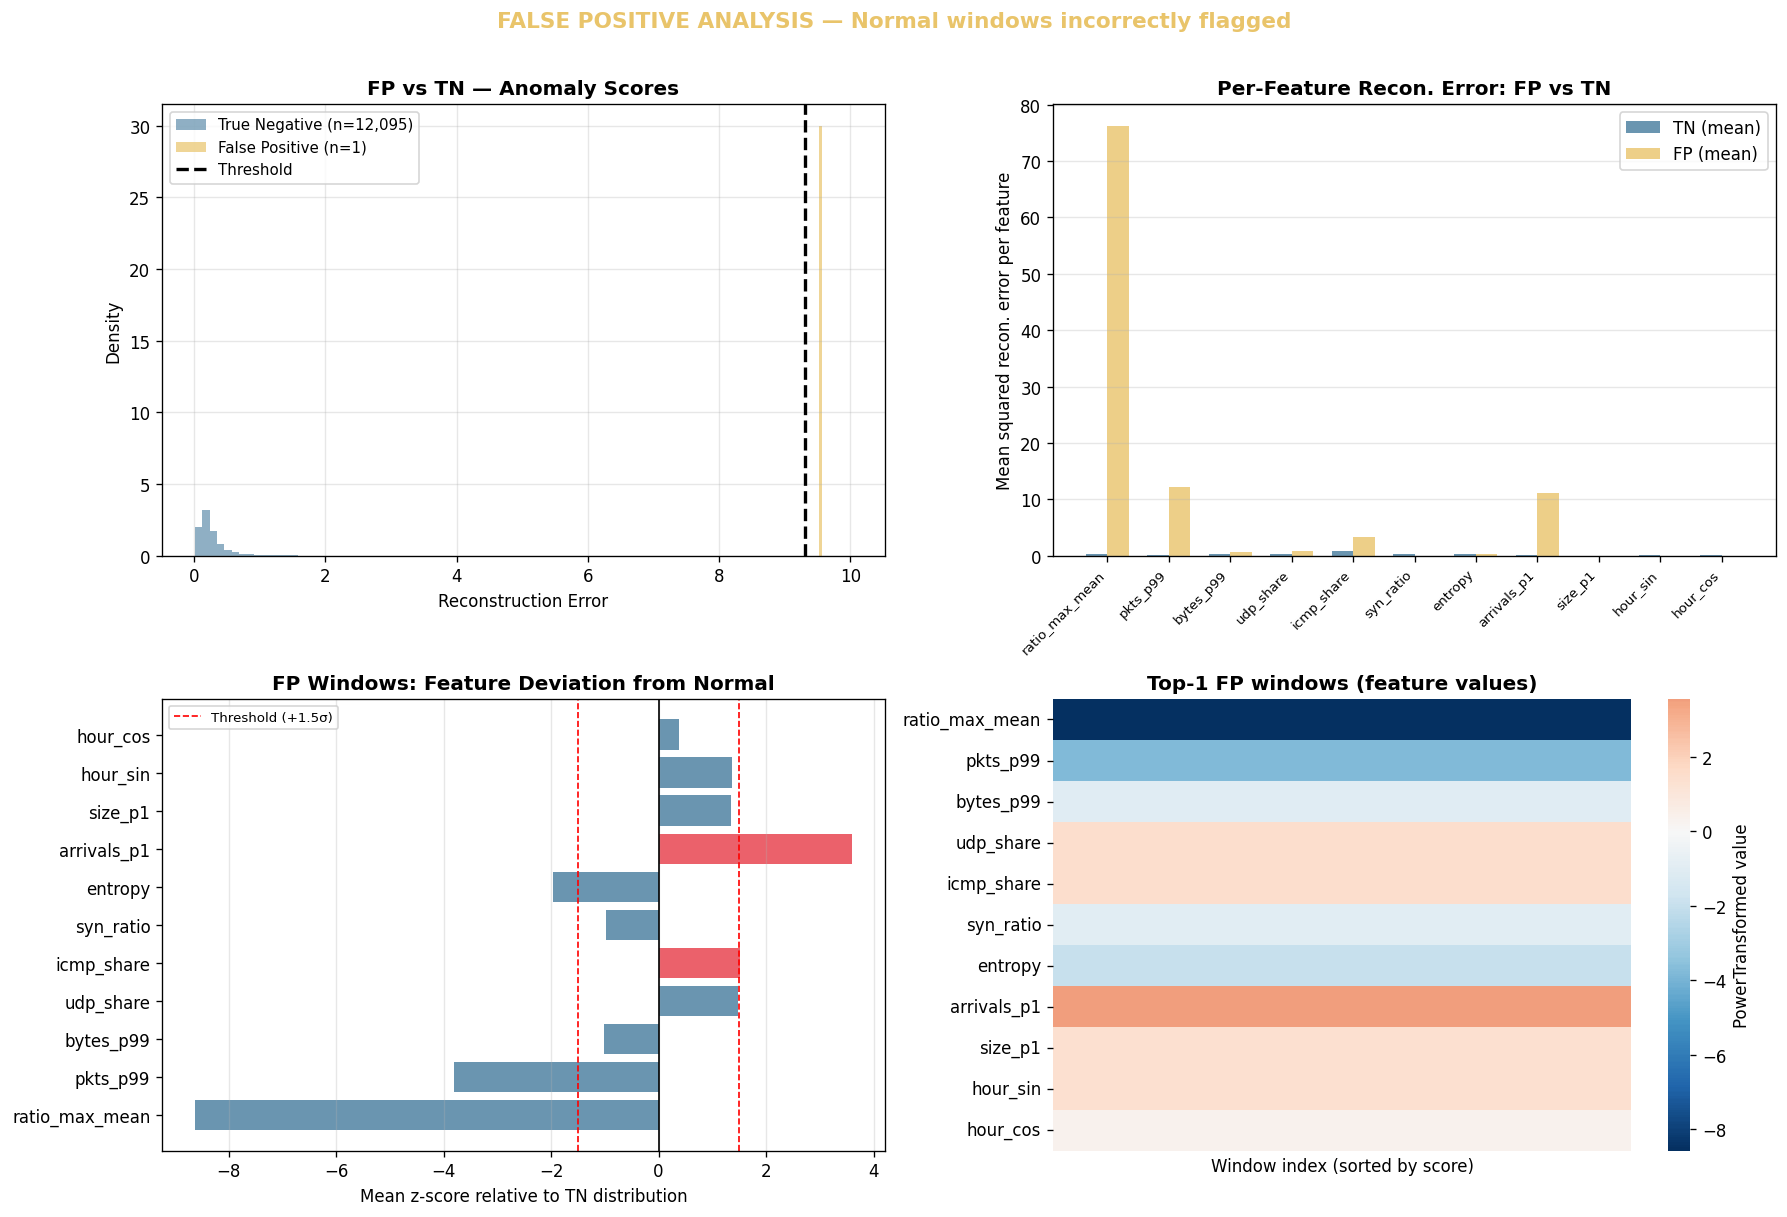


Top features causing false positives (highest positive z-score):
  arrivals_p1        : z = +3.60 (FP windows have much higher values than typical normal)
  icmp_share         : z = +1.52 (FP windows have much higher values than typical normal)
  udp_share          : z = +1.49 (FP windows have much higher values than typical normal)


In [13]:
# 11. FALSE POSITIVE ANALYSIS
#     Normal windows incorrectly flagged as attacks

if fp == 0:
    print('No false positives — perfect precision on test_final.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # ── 11a. Score distribution — FP vs TN ───────────────────
    ax = axes[0, 0]
    ax.hist(sc_test_bm[TN_mask], bins=60, alpha=0.6, color='#457B9D',
            density=True, label=f'True Negative (n={tn:,})')
    ax.hist(sc_test_bm[FP_mask], bins=30, alpha=0.7, color='#E9C46A',
            density=True, label=f'False Positive (n={fp:,})')
    ax.axvline(best_threshold, color='black', ls='--', lw=2, label='Threshold')
    ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Density')
    ax.set_title('FP vs TN — Anomaly Scores', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ── 11b. Per-feature reconstruction error: FP vs TN ──────
    ax = axes[0, 1]
    fp_feat_mean = pfeat_FP.mean(axis=0)
    tn_feat_mean = pfeat_TN.mean(axis=0)
    x = np.arange(n_features)
    width = 0.35
    ax.bar(x - width/2, tn_feat_mean, width, color='#457B9D', label='TN (mean)', alpha=0.8)
    ax.bar(x + width/2, fp_feat_mean, width, color='#E9C46A', label='FP (mean)', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(FEAT_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean squared recon. error per feature')
    ax.set_title('Per-Feature Recon. Error: FP vs TN', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')

    # ── 11c. Feature value distributions for FP windows ──────
    ax = axes[1, 0]
    fp_feat_z = ((X_FP - X_TN.mean(axis=0)) / (X_TN.std(axis=0) + 1e-8)).mean(axis=0)
    colors_bar = ['#E63946' if v > 1.5 else '#457B9D' for v in fp_feat_z]
    ax.barh(FEAT_LABELS, fp_feat_z, color=colors_bar, alpha=0.8)
    ax.axvline(0,  color='black', lw=1)
    ax.axvline(1.5, color='red', ls='--', lw=1, label='Threshold (+1.5σ)')
    ax.axvline(-1.5,color='red', ls='--', lw=1)
    ax.set_xlabel('Mean z-score relative to TN distribution')
    ax.set_title('FP Windows: Feature Deviation from Normal', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x')

    # ── 11d. Top-N FP examples: feature heatmap ──────────────
    ax = axes[1, 1]
    n_show = min(30, fp)
    fp_sorted_idx = np.argsort(sc_test_bm[FP_mask])[::-1][:n_show]
    fp_heatmap = X_FP[fp_sorted_idx]
    sns.heatmap(fp_heatmap.T, ax=ax, xticklabels=False,
                yticklabels=FEAT_LABELS, cmap='RdBu_r', center=0,
                cbar_kws={'label': 'PowerTransformed value'})
    ax.set_title(f'Top-{n_show} FP windows (feature values)', fontweight='bold')
    ax.set_xlabel('Window index (sorted by score)')

    plt.suptitle('FALSE POSITIVE ANALYSIS — Normal windows incorrectly flagged',
                 y=1.01, fontsize=13, fontweight='bold', color='#E9C46A')
    plt.tight_layout()
    plt.savefig('error_analysis_FP.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Textual summary
    top_fp_features = np.argsort(fp_feat_z)[::-1][:3]
    print('\nTop features causing false positives (highest positive z-score):')
    for i in top_fp_features:
        print(f'  {FEAT_LABELS[i]:<18} : z = {fp_feat_z[i]:+.2f} (FP windows have much higher values than typical normal)')


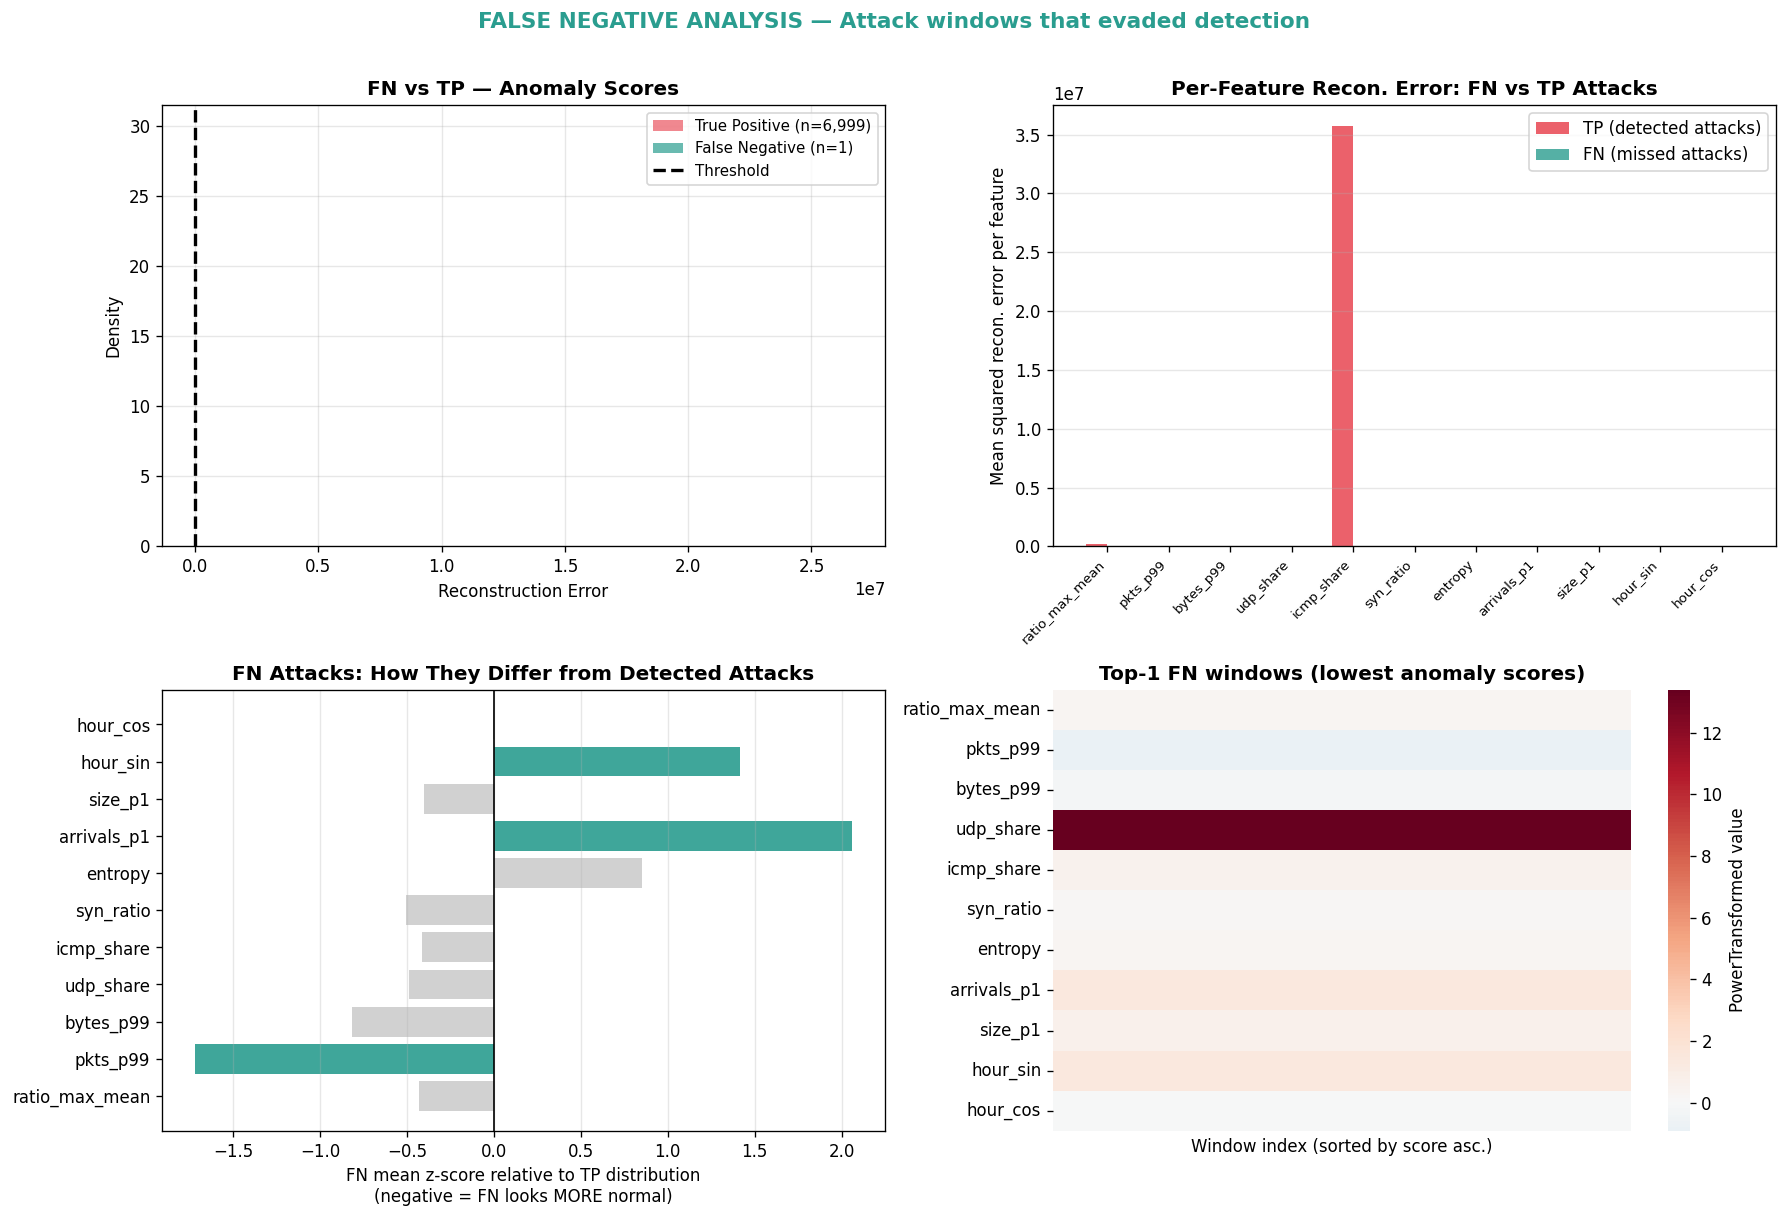


Features where FN and TP attacks look MOST similar (smallest deviation):
  hour_cos          : z = -0.00  (FN ≈ TP → not useful for detection)
  size_p1           : z = -0.40  (FN ≈ TP → not useful for detection)
  icmp_share        : z = -0.41  (FN ≈ TP → not useful for detection)

Features where FN attacks look most NORMAL (most negative z-score):
  pkts_p99          : z = -1.72  (FN has lower values → looks normal)
  bytes_p99         : z = -0.81  (FN has lower values → looks normal)
  syn_ratio         : z = -0.50  (FN has lower values → looks normal)


In [14]:
# 12. FALSE NEGATIVE ANALYSIS
#     Attack windows that escaped detection

if fn == 0:
    print('No false negatives — perfect recall on test_final.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # ── 12a. Score distribution — FN vs TP ───────────────────
    ax = axes[0, 0]
    ax.hist(sc_test_bm[TP_mask], bins=60, alpha=0.6, color='#E63946',
            density=True, label=f'True Positive (n={tp:,})')
    ax.hist(sc_test_bm[FN_mask], bins=30, alpha=0.7, color='#2A9D8F',
            density=True, label=f'False Negative (n={fn:,})')
    ax.axvline(best_threshold, color='black', ls='--', lw=2, label='Threshold')
    ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Density')
    ax.set_title('FN vs TP — Anomaly Scores', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ── 12b. Per-feature reconstruction error: FN vs TP ──────
    ax = axes[0, 1]
    fn_feat_mean = pfeat_FN.mean(axis=0)
    tp_feat_mean = pfeat_TP.mean(axis=0) if pfeat_TP is not None else np.zeros(n_features)
    x = np.arange(n_features)
    width = 0.35
    ax.bar(x - width/2, tp_feat_mean, width, color='#E63946', label='TP (detected attacks)', alpha=0.8)
    ax.bar(x + width/2, fn_feat_mean, width, color='#2A9D8F', label='FN (missed attacks)', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(FEAT_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean squared recon. error per feature')
    ax.set_title('Per-Feature Recon. Error: FN vs TP Attacks', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')

    # ── 12c. Feature deviation: FN windows vs TP windows ─────
    ax = axes[1, 0]
    if len(X_TP) > 0:
        fn_vs_tp = ((X_FN - X_TP.mean(axis=0)) / (X_TP.std(axis=0)+1e-8)).mean(axis=0)
    else:
        fn_vs_tp = X_FN.mean(axis=0)

    colors_bar = ['#2A9D8F' if abs(v) > 1 else '#cccccc' for v in fn_vs_tp]
    ax.barh(FEAT_LABELS, fn_vs_tp, color=colors_bar, alpha=0.9)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('FN mean z-score relative to TP distribution\n(negative = FN looks MORE normal)')
    ax.set_title('FN Attacks: How They Differ from Detected Attacks', fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    # ── 12d. FN heatmap ───────────────────────────────────────
    ax = axes[1, 1]
    n_show = min(30, fn)
    fn_sorted_idx = np.argsort(sc_test_bm[FN_mask])[:n_show]   # lowest scores first
    fn_heatmap = X_FN[fn_sorted_idx]
    sns.heatmap(fn_heatmap.T, ax=ax, xticklabels=False,
                yticklabels=FEAT_LABELS, cmap='RdBu_r', center=0,
                cbar_kws={'label': 'PowerTransformed value'})
    ax.set_title(f'Top-{n_show} FN windows (lowest anomaly scores)', fontweight='bold')
    ax.set_xlabel('Window index (sorted by score asc.)')

    plt.suptitle('FALSE NEGATIVE ANALYSIS — Attack windows that evaded detection',
                 y=1.01, fontsize=13, fontweight='bold', color='#2A9D8F')
    plt.tight_layout()
    plt.savefig('error_analysis_FN.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Textual summary
    smallest_fn_gap = np.argsort(np.abs(fn_vs_tp))[:3]
    print('\nFeatures where FN and TP attacks look MOST similar (smallest deviation):')
    for i in smallest_fn_gap:
        print(f'  {FEAT_LABELS[i]:<18}: z = {fn_vs_tp[i]:+.2f}  (FN ≈ TP → not useful for detection)')

    largest_fn_gap = np.argsort(fn_vs_tp)[:3]
    print('\nFeatures where FN attacks look most NORMAL (most negative z-score):')
    for i in largest_fn_gap:
        print(f'  {FEAT_LABELS[i]:<18}: z = {fn_vs_tp[i]:+.2f}  (FN has lower values → looks normal)')

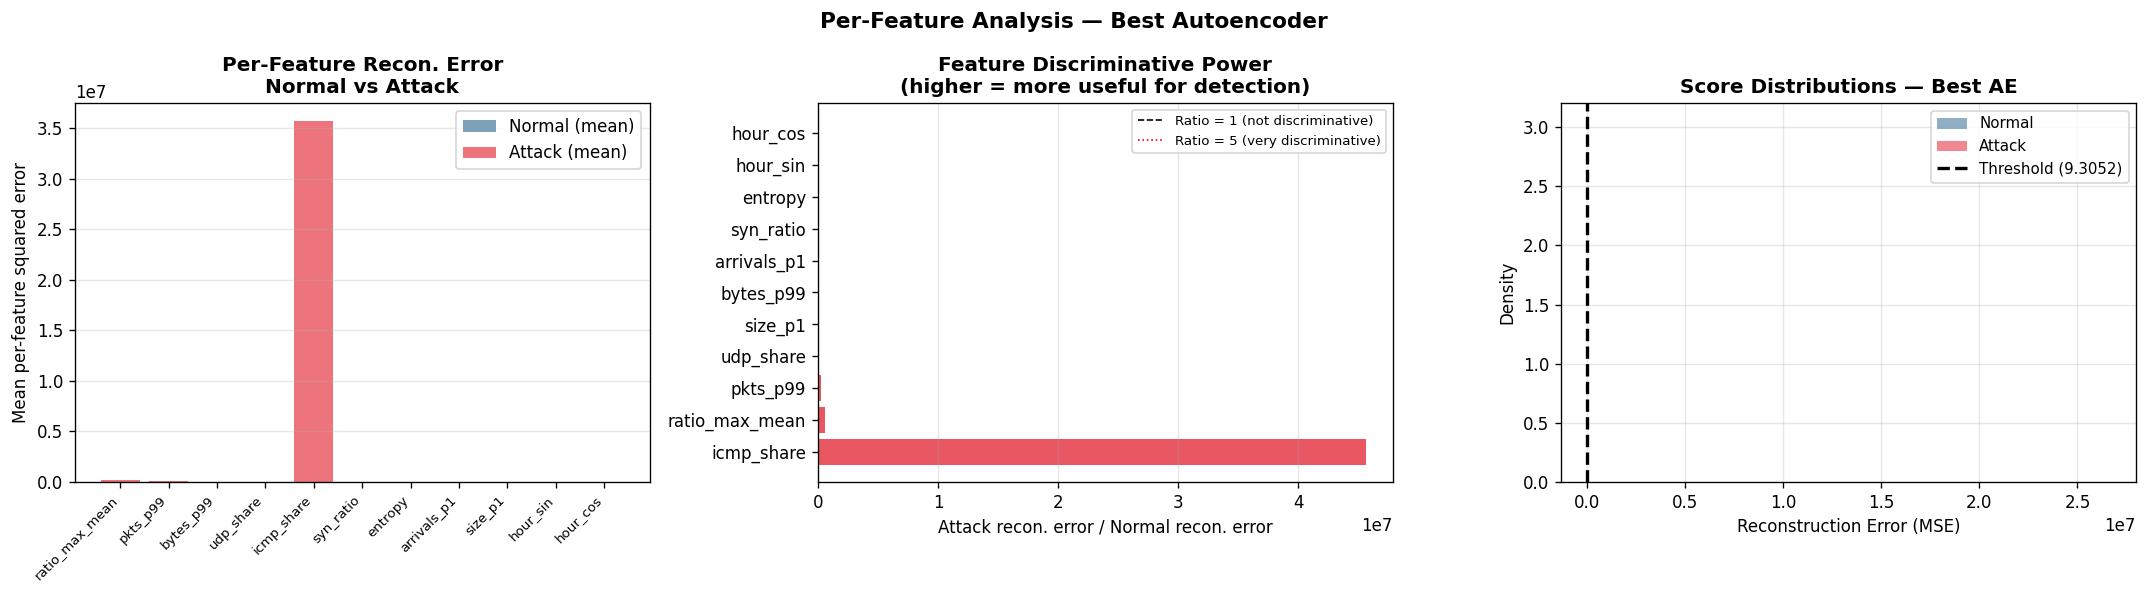


=== FEATURE DISCRIMINATIVE POWER (attack/normal error ratio) ===
  icmp_share          : ratio = 45580480.00  ***
  ratio_max_mean      : ratio = 562357.00  ***
  pkts_p99            : ratio = 244663.72  ***
  udp_share           : ratio = 49461.62  ***
  size_p1             : ratio = 17659.74  ***
  bytes_p99           : ratio = 15954.29  ***
  arrivals_p1         : ratio = 4445.20  ***
  syn_ratio           : ratio =  315.87  ***
  entropy             : ratio =   37.32  ***
  hour_sin            : ratio =   22.46  ***
  hour_cos            : ratio =    6.69  ***


In [15]:
# 13. PER-FEATURE RECONSTRUCTION ERROR HEATMAP
#     Which features drive the anomaly score up for attacks?
#     Which are uninformative (same error for normal and attack)?

pfeat_normal_all = get_per_feature_scores(best_model, X_test_pt[y_test_final==0])
pfeat_attack_all = get_per_feature_scores(best_model, X_test_pt[y_test_final==1])

mean_normal_feat = pfeat_normal_all.mean(axis=0)
mean_attack_feat = pfeat_attack_all.mean(axis=0)
ratio_feat = mean_attack_feat / (mean_normal_feat + 1e-10)  # attack / normal

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Feature discriminative power ──────────────────────────────
ax = axes[0]
x = np.arange(n_features)
ax.bar(x, mean_normal_feat, alpha=0.7, color='#457B9D', label='Normal (mean)')
ax.bar(x, mean_attack_feat, alpha=0.7, color='#E63946', label='Attack (mean)')
ax.set_xticks(x); ax.set_xticklabels(FEAT_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean per-feature squared error')
ax.set_title('Per-Feature Recon. Error\nNormal vs Attack', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# ── Attack/Normal ratio ────────────────────────────────────────
ax = axes[1]
rank_idx = np.argsort(ratio_feat)[::-1]
bar_colors = ['#E63946' if r > 5 else '#E9C46A' if r > 2 else '#457B9D'
              for r in ratio_feat[rank_idx]]
ax.barh([FEAT_LABELS[i] for i in rank_idx],
        ratio_feat[rank_idx], color=bar_colors, alpha=0.85)
ax.axvline(1, color='black', lw=1, ls='--', label='Ratio = 1 (not discriminative)')
ax.axvline(5, color='red',   lw=1, ls=':', label='Ratio = 5 (very discriminative)')
ax.set_xlabel('Attack recon. error / Normal recon. error')
ax.set_title('Feature Discriminative Power\n(higher = more useful for detection)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x')

# ── Distribution of scores: normal vs attack ──────────────────
ax = axes[2]
ax.hist(sc_test_bm[y_test_final==0], bins=80, alpha=0.6, color='#457B9D',
        density=True, label='Normal')
ax.hist(sc_test_bm[y_test_final==1], bins=80, alpha=0.6, color='#E63946',
        density=True, label='Attack')
ax.axvline(best_threshold, color='black', ls='--', lw=2,
           label=f'Threshold ({best_threshold:.4f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Score Distributions — Best AE', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Per-Feature Analysis — Best Autoencoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== FEATURE DISCRIMINATIVE POWER (attack/normal error ratio) ===')
for i in rank_idx:
    stars = '***' if ratio_feat[i] > 5 else '**' if ratio_feat[i] > 2 else ' '
    print(f"  {FEAT_LABELS[i]:<20}: ratio = {ratio_feat[i]:>7.2f}  {stars}")

=== Per-Cluster Attack Analysis ===
  Cluster 0 [UDP Flood (?)]: n=5,466  detection=100.0%  median_score=9357.6230
  Cluster 1 [ICMP Flood (?)]: n=197  detection=100.0%  median_score=17515964.0000
  Cluster 2 [ICMP Flood (?)]: n=113  detection=100.0%  median_score=10677927.0000
  Cluster 3 [ICMP Flood (?)]: n=738  detection=100.0%  median_score=24817278.0000
  Cluster 4 [UDP Flood (?)]: n=486  detection=100.0%  median_score=145860.3125


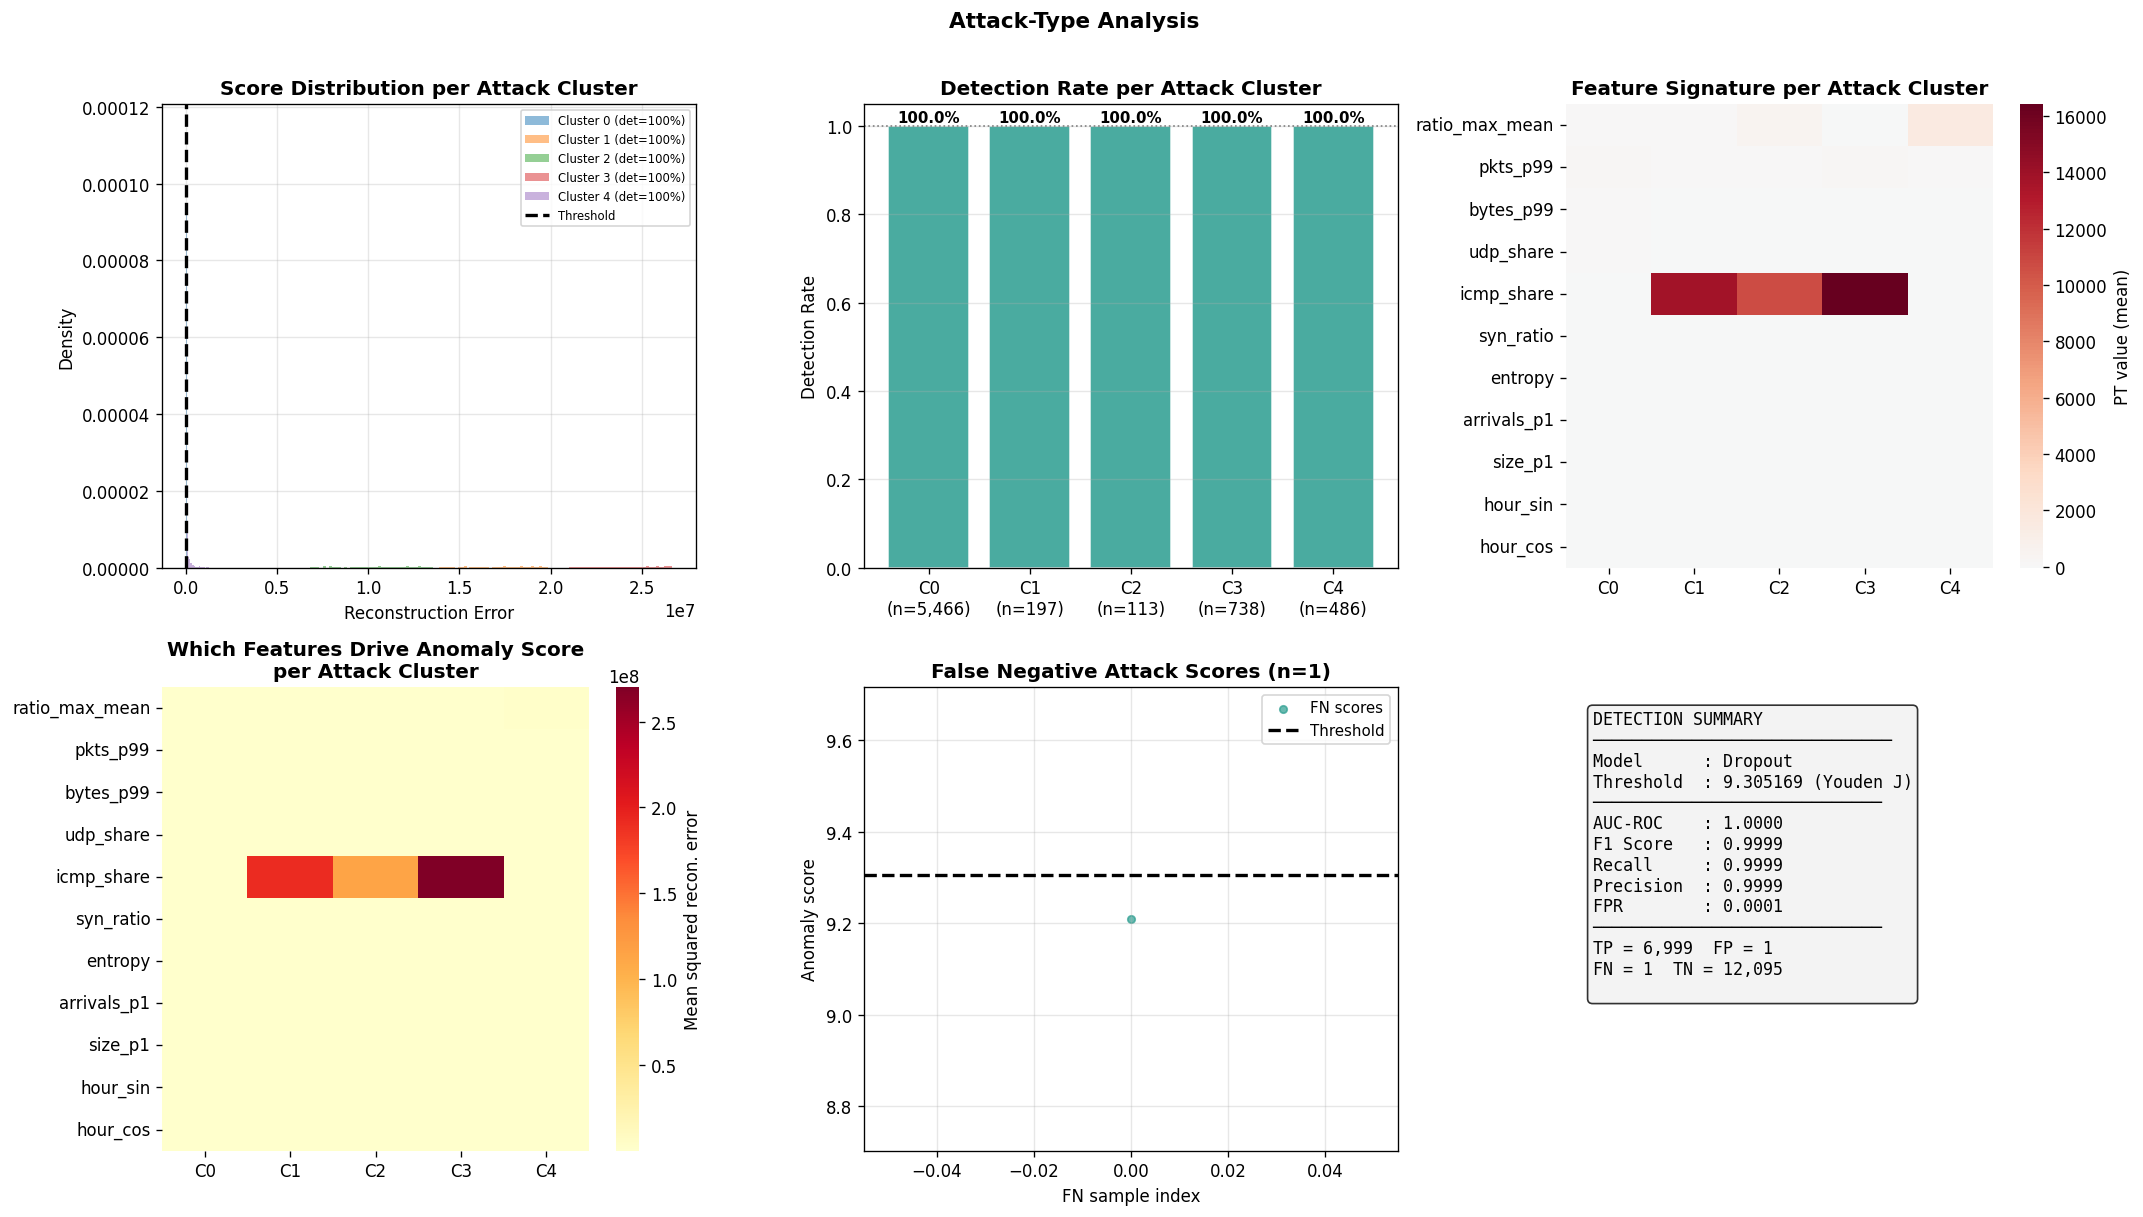

In [16]:
# 14. ATTACK-TYPE ANALYSIS
#     Since test_final only has binary labels (0/1), we cluster
#     the attack windows and analyse per-cluster detection.
#     We also try to identify attack types from feature signatures:
#       icmp_flood  → high icmp_share
#       udp_flood   → high udp_share
#       syn_flood   → high syn_ratio, small packets
#       http_flood  → high pkts, TCP
#       amplification → high bytes, high frag

from sklearn.cluster import KMeans

X_attacks = X_test_pt[y_test_final == 1]
# Use the ORIGINAL (non-power-transformed) normalized features for interpretability
X_attacks_orig = X_test_final[y_test_final == 1]  # original index
X_atk_raw = df_test[FEATURES].values[np.where(y_all == 1)[0]]
# Re-index to test_final attack positions:
atk_indices_in_test = np.where(y_test_final == 1)[0]

# Cluster attacks into 5 groups (we generated 5 attack types)
km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
atk_clusters = km.fit_predict(X_attacks)

# Compute detection rate per cluster (using pct99 threshold for comparability)
sc_attacks  = sc_test_bm[y_test_final == 1]
detected    = (sc_attacks > best_threshold).astype(int)

print('=== Per-Cluster Attack Analysis ===')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cluster_stats = []
for c in range(5):
    mask_c = (atk_clusters == c)
    det_rate = detected[mask_c].mean() if mask_c.sum() > 0 else 0
    score_median = np.median(sc_attacks[mask_c]) if mask_c.sum() > 0 else 0

    # Mean feature values for this cluster
    feat_mean = X_attacks[mask_c].mean(axis=0)
    cluster_stats.append({
        'cluster': c,
        'n': int(mask_c.sum()),
        'detection_rate': det_rate,
        'score_median': score_median,
        **{f: float(feat_mean[i]) for i, f in enumerate(FEAT_LABELS)},
    })

    # Try to name the cluster from feature signatures
    feat_dict = dict(zip(FEAT_LABELS, feat_mean))
    if feat_dict.get('icmp_share', 0) > 1.0:   cname = 'ICMP Flood (?)'
    elif feat_dict.get('udp_share', 0) > 1.0:  cname = 'UDP Flood (?)'
    elif feat_dict.get('syn_ratio', 0) > 2.0:  cname = 'SYN Flood (?)'
    elif feat_dict.get('bytes_p99', 0) > 2.0:  cname = 'Amplification (?)'
    else:                                        cname = 'HTTP Flood (?)'

    print(f'  Cluster {c} [{cname}]: n={mask_c.sum():,}  detection={det_rate:.1%}  median_score={score_median:.4f}')

# ── Score distribution per cluster ───────────────────────────
ax = axes[0, 0]
for c in range(5):
    mask_c = (atk_clusters == c)
    if mask_c.sum() > 0:
        ax.hist(sc_attacks[mask_c], bins=40, alpha=0.5,
                label=f'Cluster {c} (det={cluster_stats[c]["detection_rate"]:.0%})',
                density=True)
ax.axvline(best_threshold, color='black', ls='--', lw=2, label='Threshold')
ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Density')
ax.set_title('Score Distribution per Attack Cluster', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Detection rate per cluster ────────────────────────────────
ax = axes[0, 1]
det_rates  = [r['detection_rate'] for r in cluster_stats]
clus_names = [f'C{r["cluster"]}\n(n={r["n"]:,})' for r in cluster_stats]
colors = ['#E63946' if d < 0.95 else '#2A9D8F' for d in det_rates]
ax.bar(clus_names, det_rates, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='grey', ls=':', lw=1)
ax.set_ylabel('Detection Rate'); ax.set_ylim([0, 1.05])
ax.set_title('Detection Rate per Attack Cluster', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for i, d in enumerate(det_rates):
    ax.text(i, d+0.01, f'{d:.1%}', ha='center', fontsize=9, fontweight='bold')

# ── Feature heatmap per cluster ───────────────────────────────
ax = axes[0, 2]
cluster_means = np.array([[cluster_stats[c][f] for f in FEAT_LABELS] for c in range(5)])
sns.heatmap(cluster_means.T, ax=ax,
            xticklabels=[f'C{c}' for c in range(5)],
            yticklabels=FEAT_LABELS,
            cmap='RdBu_r', center=0, cbar_kws={'label': 'PT value (mean)'})
ax.set_title('Feature Signature per Attack Cluster', fontweight='bold')

# ── Reconstruction error per cluster per feature ──────────────
ax = axes[1, 0]
clus_feat_err = []
for c in range(5):
    mask_c = (atk_clusters == c)
    if mask_c.sum() > 0:
        err = get_per_feature_scores(best_model, X_attacks[mask_c]).mean(axis=0)
    else:
        err = np.zeros(n_features)
    clus_feat_err.append(err)

clus_feat_err = np.array(clus_feat_err)  # (5, 11)
sns.heatmap(clus_feat_err.T, ax=ax,
            xticklabels=[f'C{c}' for c in range(5)],
            yticklabels=FEAT_LABELS,
            cmap='YlOrRd', cbar_kws={'label': 'Mean squared recon. error'})
ax.set_title('Which Features Drive Anomaly Score\nper Attack Cluster', fontweight='bold')

# ── Missed attacks feature deviation ─────────────────────────
ax = axes[1, 1]
if fn > 0:
    fn_indices = np.where(FN_mask)[0]
    fn_clusters = atk_clusters[np.searchsorted(atk_indices_in_test, fn_indices)] \
                  if len(fn_indices) > 0 else []

    # Safe: just show FN score distribution vs all attacks
    ax.scatter(range(fn), sc_attacks[~detected.astype(bool)],
               color='#2A9D8F', s=20, alpha=0.7, label='FN scores')
    ax.axhline(best_threshold, color='black', ls='--', lw=2, label='Threshold')
    ax.set_xlabel('FN sample index'); ax.set_ylabel('Anomaly score')
    ax.set_title(f'False Negative Attack Scores (n={fn})', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No False Negatives!\nAll attacks detected.',
            ha='center', va='center', fontsize=14, fontweight='bold',
            color='#2A9D8F', transform=ax.transAxes)
    ax.set_title('False Negative Scores', fontweight='bold')

# ── Overall detection summary ────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
summary_text = (
    f"DETECTION SUMMARY\n"
    f"{'─'*30}\n"
    f"Model      : {best_arch}\n"
    f"Threshold  : {best_threshold:.6f} ({best_thresh_method})\n"
    f"─────────────────────────────\n"
    f"AUC-ROC    : {arch_results[best_arch]['AUC']:.4f}\n"
    f"F1 Score   : {thresh_methods[best_thresh_method]['F1']:.4f}\n"
    f"Recall     : {thresh_methods[best_thresh_method]['Recall']:.4f}\n"
    f"Precision  : {thresh_methods[best_thresh_method]['Prec']:.4f}\n"
    f"FPR        : {thresh_methods[best_thresh_method]['FPR']:.4f}\n"
    f"─────────────────────────────\n"
    f"TP = {tp:,}  FP = {fp:,}\n"
    f"FN = {fn:,}  TN = {tn:,}\n"
)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=10, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.suptitle('Attack-Type Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('attack_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# 15. FINAL SUMMARY — BEST AUTOENCODER

print('='*70)
print('FINAL AUTOENCODER SUMMARY')
print('='*70)

print('\n── Architecture ────────────────────────────────────────────')
print(f'  Name      : {best_arch}')
print(f'  Params    : {arch_results[best_arch]["n_params"]:,}')
print(f'  J_train   : {arch_results[best_arch]["J_train_final"]:.6f}')
print(f'  J_cv      : {arch_results[best_arch]["J_cv_final"]:.6f}')
print(f'  Best epoch: {arch_results[best_arch]["best_epoch"]}')

print('\n── Threshold ───────────────────────────────────────────────')
print(f'  Method    : {best_thresh_method}')
print(f'  Value     : {best_threshold:.6f}')

print('\n── Detection Performance (test_final) ──────────────────────')
for metric, val in thresh_methods[best_thresh_method].items():
    if metric != 'threshold':
        print(f'  {metric:<8}: {val:.4f}')

print('\n── Bias-Variance Diagnosis ─────────────────────────────────')
tr = arch_results[best_arch]['J_train_final']
cv = arch_results[best_arch]['J_cv_final']
ratio = cv / tr
print(f'  J_cv / J_train = {ratio:.3f}')
if ratio < 1.05:
    print('  → LOW VARIANCE (no overfitting). Model fits normal well and generalises.')
    print('  → If F1 < 1.0, the issue is the threshold, not the model capacity.')
elif ratio < 1.3:
    print('  → MILD VARIANCE. Adding Dropout or more weight decay may help slightly.')
else:
    print('  → HIGH VARIANCE. The model overfits. Reduce capacity or add regularisation.')

print('\n── Baseline Comparison ────────────────────────────────────')
for name, r in baseline_results.items():
    print(f'  {name:<28}: AUC={r["AUC"]:.4f}  F1={r["F1"]:.4f}')
print(f'  {"Best AE ("+best_arch+")":<28}: AUC={arch_results[best_arch]["AUC"]:.4f}  '
      f'F1={thresh_methods[best_thresh_method]["F1"]:.4f}')

print('\n── Recommendation for the FL System ───────────────────────')
print(f'  Use architecture : {best_arch}')
print(f'  Threshold method : {best_thresh_method}')
print(f'  Threshold value  : calibrate on val_normal of each FL client using pct99,')
print(f'                     then fine-tune with Youden J on any available labeled samples.')
print(f'  FL aggregation   : FedAvg on encoder + decoder weights (all parameters)')
print('='*70)

FINAL AUTOENCODER SUMMARY

── Architecture ────────────────────────────────────────────
  Name      : Dropout
  Params    : 2,033
  J_train   : 0.386310
  J_cv      : 0.281990
  Best epoch: 72

── Threshold ───────────────────────────────────────────────
  Method    : Youden J
  Value     : 9.305169

── Detection Performance (test_final) ──────────────────────
  F1      : 0.9999
  Recall  : 0.9999
  Prec    : 0.9999
  FPR     : 0.0001

── Bias-Variance Diagnosis ─────────────────────────────────
  J_cv / J_train = 0.730
  → LOW VARIANCE (no overfitting). Model fits normal well and generalises.
  → If F1 < 1.0, the issue is the threshold, not the model capacity.

── Baseline Comparison ────────────────────────────────────
  Mahalanobis (pct99)         : AUC=1.0000  F1=0.9909
  3σ Rule (pct99)             : AUC=1.0000  F1=0.9903
  PCA Recon. (pct99)          : AUC=0.9840  F1=0.9619
  AE (pct99 — reference)      : AUC=1.0000  F1=0.9903
  Best AE (Dropout)           : AUC=1.0000  F1=0.9999